# About dataset
- 

Importing required libraries

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Loading csv file of the student performance dataset from local folder after downloaded from kaggle

In [101]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


#### 5 Business Questions from this dataset
- Student whose parent's has higher degree does score high marks?
- Does completion of test preparation course affects marks
- Which group has scored more marks has good average
- Which group has higher female and male
- Does female scored more marks than male? 

Checking for dtypes and null vales

- No null values found
- All the datatypes is correctly assigned

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


Checking distributions

- Zero nulls — all columns count 1000
- Math score mean 66, reading 69, writing 68 — all similar ranges
- Math has min of 0 — suspicious, worth investigating
- Most common race/ethnicity is group C, most common parental education is "some college"
- Test prep "none" is most common — 642 out of 1000 didn't complete it

In [103]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [104]:
df.describe(include='object')

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


Univariate Analysis
- In math score female scored less marks than male, after 70 marks male shows full dominance, Males are high scorer in math score
- In reading score most female scored marks between 70-100 and most male scored less marks between 40-70, Females are high scorer in reading score
- In writing score same majority females are the high scorer more females scored marks between 70-100 and more male scored marks between 35-65
> All 3 score distributions are approximately normal, no significant skew. No log transformation needed.

#### conclusion
- Female scores higher in reading and writing score and male scored higher in math 

<Axes: xlabel='math score', ylabel='Count'>

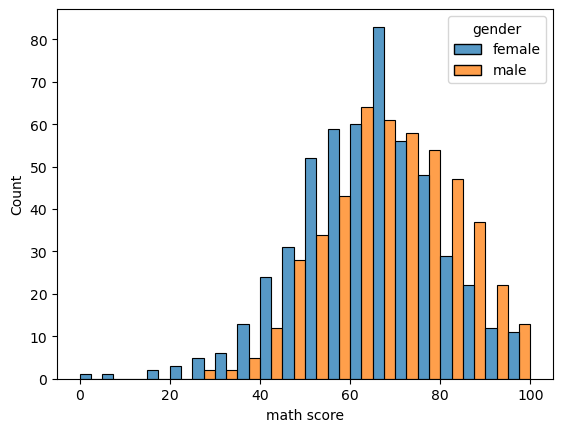

In [105]:
sns.histplot(df, x='math score', bins=20, hue='gender', multiple='dodge')

<Axes: xlabel='reading score', ylabel='Count'>

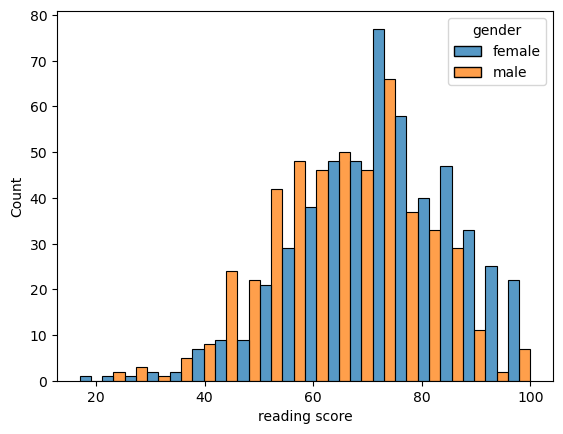

In [106]:
sns.histplot(df, x='reading score', bins=20, hue='gender', multiple='dodge')

<Axes: xlabel='writing score', ylabel='Count'>

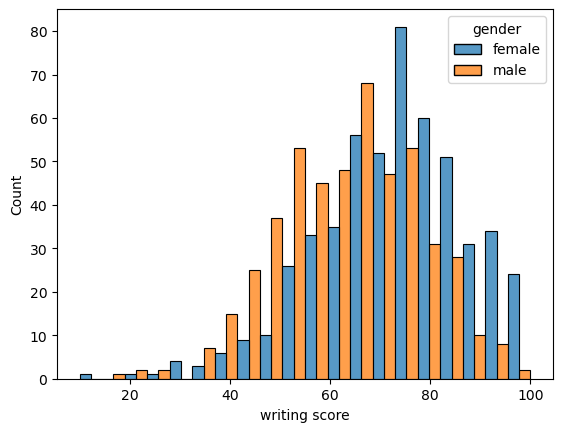

In [107]:
sns.histplot(df, x='writing score', bins=20, hue='gender', multiple='dodge')

Does gender affects total marks show below

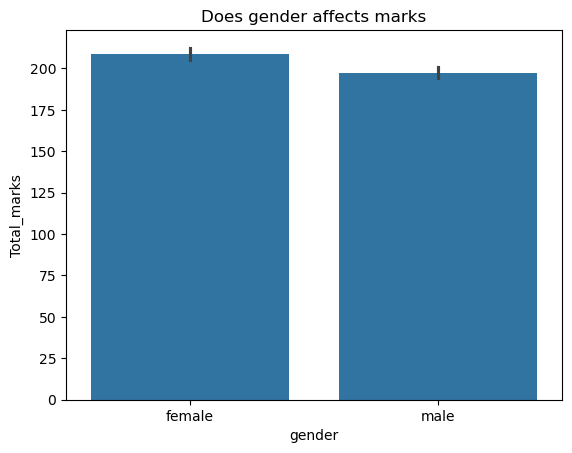

In [122]:
sns.barplot(df, x='gender', y='Total_marks')
plt.title("Does gender affects marks")
plt.show()

Bivariate Analysis
- For all three subject student whose parent has master degree scores higher marks
- Student whose parent only completed high school score less marks in all three subjects 
- Relationship is mostly linear — higher parental education generally means higher scores. One exception: high school completers score lower than some high school, which breaks the expected pattern

#### Conclusion
Students whose parents have higher degree scores good marks in all subjects and vice versa

In [109]:
df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean().round(2).sort_values(by=['math score', 'reading score', 'writing score'],ascending=False)

,math score,reading score,writing score
parental level of education,,,
master's degree,69.75,75.37,75.68
bachelor's degree,69.39,73.00,73.38
associate's degree,67.88,70.93,69.90
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89
high school,62.14,64.70,62.45


Visualization on Parent's degree impact on student marks

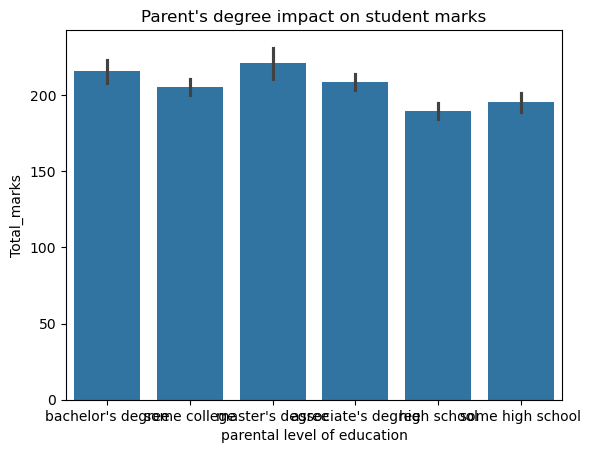

In [121]:
sns.barplot(df, x='parental level of education', y='Total_marks')
plt.title("Parent's degree impact on student marks")
plt.show()

Creating new column called total_marks which contains total marks of all three subjects of every student

In [112]:
df['Total_marks'] = df['reading score'] + df['math score'] + df['writing score']
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


Bivariate analysis
- Students who compeleted test have higher chance of scoring more marks with mean (218.01) than who has not given test(195.12)
> Students who completed test prep scored on average 23 marks higher out of 300 — roughly 7.6% improvement. Test preparation has a meaningful impact on performance.

In [113]:
df.groupby('test preparation course')['Total_marks'].mean().round(2)

test preparation course
completed    218.01
none         195.12
Name: Total_marks, dtype: float64

#### Visualization of test prep impact on scores
- students who completed the test has higher median than not completed student
- The IQR range of completed test student has higher in range than no completed
- None has more outliers and student scoring in low range 25-75, completed student is lower is ~108. Test completion lower the chance of poor performance
- Top performer exists in both the group with ~300 means some student score good regardless

C:\Users\Asus\AppData\Local\Temp\ipykernel_5612\297370821.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test preparation course', y='Total_marks', data=df, palette='coolwarm')


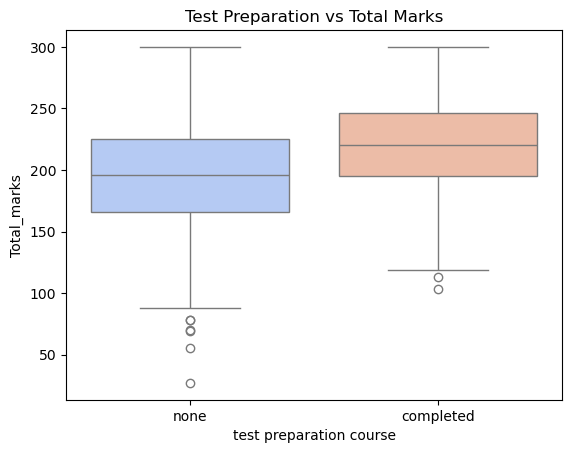

In [114]:
sns.boxplot(x='test preparation course', y='Total_marks', data=df, palette='coolwarm')
plt.title('Test Preparation vs Total Marks')
plt.show()

No. of students who has not completed test preparation
none = ~630 and completed = ~350

<Axes: xlabel='test preparation course', ylabel='count'>

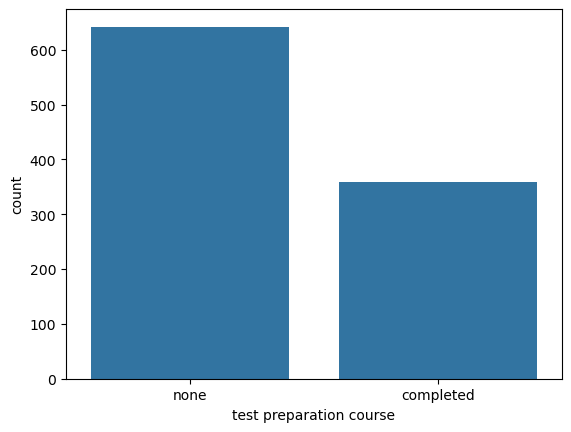

In [115]:
sns.countplot(df, x='test preparation course')

Grouping race/ethnicity and total marks col
- Group E students more average 218.26
- Group A students has the lowest avg 188.98
- A 29 points of difference across the groups
- Group E > D > C > B > A

In [138]:
df.groupby('race/ethnicity')['Total_marks'].mean().sort_values(ascending=False)

race/ethnicity
group E    218.257143
group D    207.538168
group C    201.394984
group B    196.405263
group A    188.977528
Name: Total_marks, dtype: float64

Which group has highest avg marks visualisation

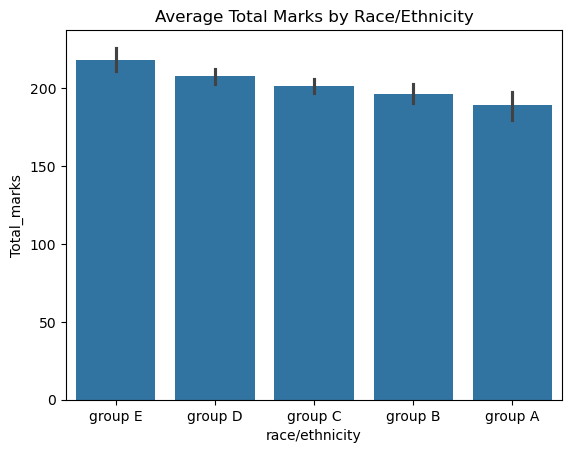

In [139]:
orderr = df.groupby('race/ethnicity')['Total_marks'].mean().sort_values(ascending=False).index.tolist()
sns.barplot(data=df, x='race/ethnicity', y='Total_marks', order= orderr)
plt.title('Average Total Marks by Race/Ethnicity')
plt.show()

Lunch feature affects on total_marks of the student or not
- Yes it does observation shows 

In [118]:
df.groupby('lunch')['Total_marks'].mean().round(2).sort_values(ascending=False)

lunch
standard        212.51
free/reduced    186.60
Name: Total_marks, dtype: float64

#### Observation of heatmap correlation
- All three subjects are positively correlated — a student doing well in one tends to do well in others
- Reading & Writing are almost measuring the same skill (0.95 is very high)
- Math is slightly more independent compared to reading/writing

<Axes: >

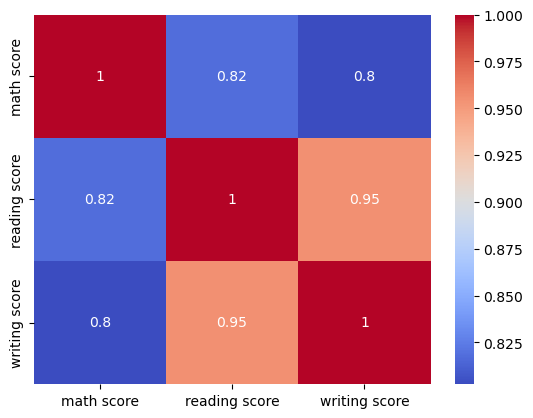

In [119]:
sns.heatmap(df[['math score','reading score' ,'writing score']].corr(), annot=True, cmap='coolwarm')

# Conclusion'
`Dataset Overveiw`
- This data is about student performace got affected on what factors
- There is no missing values, dataset is well balanced and there are 1000 rows and 8 columns

`Top 3 features on which student performance/score depends`
1) test preparation course col has the highest dependance of how a student will score 
2) parental level of education is also a feature on which marks depends as saw previously higher the degree of parent higher their student score
3) race/ethnicity, if you belongs to group E or group D your chance of scoring good marks is higher

`What ML model would you try first and why`
- For this dataset the goal would be to predict a student's score range (high/medium/low) based on demographic features. I would try Linear Regression first to predict actual score values since all three scores are continuous numerical targets. Random Forest would be second choice as it handles categorical features like parental education and race/ethnicity better and can capture non-linear relationships between features.